<a href="https://colab.research.google.com/github/Shubh3155/deep-learning/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YOLO libraries ready ✅
YOLO loaded ✅
Total classes YOLO knows : 80
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter image path (Drive path / URL / local): https://drive.google.com/file/d/1eC1wgIE3ZHsbR2Ux4XTZB3yLcyQFzK9W/view?usp=drive_link
🌐 Loading image from URL...

0: 384x640 8 persons, 314.6ms
Speed: 31.6ms preprocess, 314.6ms inference, 43.3ms postprocess per image at shape (1, 3, 384, 640)


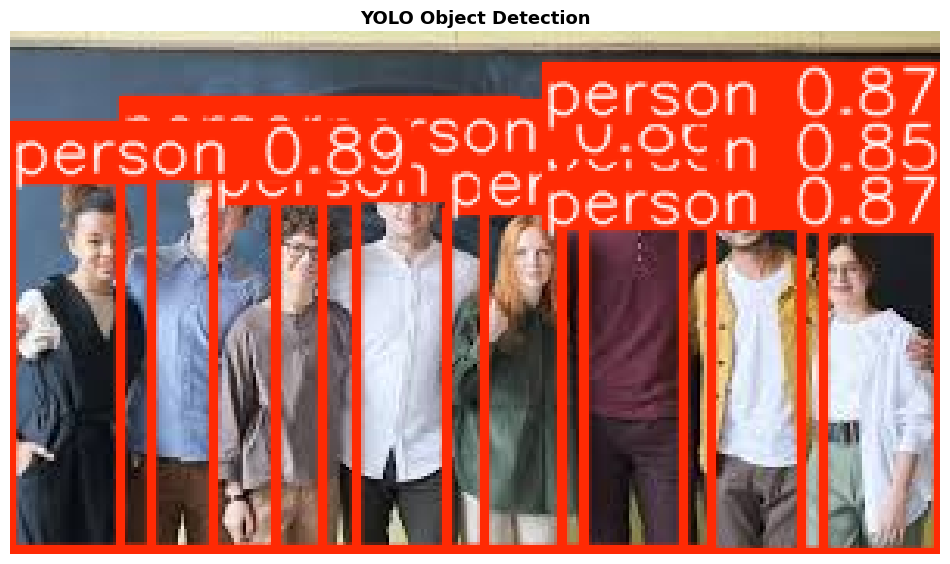


=== Detected Objects ===
person          → 88.7%
person          → 86.8%
person          → 86.7%
person          → 86.3%
person          → 85.1%
person          → 84.1%
person          → 79.8%
person          → 74.5%


In [10]:
# Install libraries
!pip install ultralytics opencv-python pillow matplotlib -q
print("YOLO libraries ready ✅")

# Load YOLO
from ultralytics import YOLO
model_yolo = YOLO('yolov8n.pt')

print("YOLO loaded ✅")
print(f"Total classes YOLO knows : {len(model_yolo.names)}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── INFERENCE ─────────────────────────
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import os

image_path = input("Enter image path (Drive path / URL / local): ")

# 🔥 SMART IMAGE LOADER
if image_path.startswith("http"):
    print("🌐 Loading image from URL...")

    # Handle Google Drive links
    if "drive.google.com" in image_path:
        if "id=" in image_path:
            file_id = image_path.split("id=")[1]
        elif "/d/" in image_path:
            file_id = image_path.split("/d/")[1].split("/")[0]
        else:
            raise Exception("❌ Invalid Google Drive link format")

        image_path = f"https://drive.google.com/uc?id={file_id}"

    response = requests.get(image_path)

    if response.status_code != 200:
        raise Exception("❌ Failed to download image")

    try:
        img = Image.open(BytesIO(response.content)).convert('RGB')
    except:
        raise Exception("❌ File is not a valid image (check sharing permissions)")

else:
    print("📁 Loading image from Drive/local path...")

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"❌ File not found: {image_path}")

    img = Image.open(image_path).convert('RGB')

# Convert to numpy
img_array = np.array(img)

# Run YOLO
results = model_yolo(img_array)

# Annotated output
annotated = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.title("YOLO Object Detection", fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

# Print detections
print("\n=== Detected Objects ===")
for box in results[0].boxes:
    class_id   = int(box.cls)
    label      = model_yolo.names[class_id]
    confidence = round(float(box.conf) * 100, 1)
    print(f"{label:<15} → {confidence}%")